In [1]:
import sys
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx 

# 1. Point to our local GCAD engine so 'define_circuit' unpickles safely
current_dir = os.getcwd()
gcad_engine_dir = os.path.join(current_dir, 'GCAD')

if gcad_engine_dir not in sys.path:
    sys.path.append(gcad_engine_dir)

import define_circuit
print("✅ GCAD linked. Ready to unpickle.")

✅ GCAD linked. Ready to unpickle.


In [2]:
INPUT_DIR = os.path.join(current_dir, 'gcad_inputs')

def abstract_edges(edge_list):
    """Maps specific parts to generic roles (Input, Output, Activator, Repressor)."""
    generic = []
    for u, v in edge_list:
        src = 'P1' if u == 'P1' else ('A' if u.startswith('Z') else ('R' if u.startswith('I') else u))
        tgt = 'Rep' if v == 'Rep' else ('A' if v.startswith('Z') else ('R' if v.startswith('I') else v))
        generic.append((src, tgt))
    return tuple(sorted(generic))

def load_and_process_data(folder):
    """Loads miner results and prepares DataFrame with signatures."""
    df = pd.read_pickle(os.path.join(folder, "final_objectives_df.pkl"))
    with open(os.path.join(folder, "final_population.pkl"), "rb") as f:
        pop = pickle.load(f)
        
    print(f"Loaded {len(pop)} Final Winners.")
    
    # Attach Circuit Objects & Fix Signs
    df['circuit_object'] = [ind[0] for ind in pop]
    if 'prominence_rel' in df.columns and df['prominence_rel'].mean() < 0:
        df['prominence_rel'] = -df['prominence_rel'] # Min -> Max
        
    # Generate Signatures
    df['topology_sig'] = df['circuit_object'].apply(lambda c: str(tuple(sorted(c.edge_list))))
    df['abstract_sig'] = df['circuit_object'].apply(lambda c: abstract_edges(c.edge_list))
    
    return df

final_df = load_and_process_data(INPUT_DIR)

# Filter for Valid Pulses
valid_df = final_df[final_df['prominence_rel'] > 0.1].copy()
print(f"Analyzing {len(valid_df)} Valid Pulse Generators.")

Loaded 200 Final Winners.
Analyzing 200 Valid Pulse Generators.


In [3]:
M_TARGET = 3
selected_circuits = []

print("\n--- Searching for Diverse Architectures ---")

# Group by Abstract Signature to see the top architectures
abs_counts = valid_df['abstract_sig'].value_counts().reset_index()
abs_counts.columns = ['abstract_sig', 'Count']
top_archs = abs_counts.head(M_TARGET)

# For each top abstract architecture, pick its absolute best specific circuit
for i, row in top_archs.iterrows():
    arch_sig = row['abstract_sig']
    
    # Get all circuits that have this abstract wiring
    subset = valid_df[valid_df['abstract_sig'] == arch_sig]
    
    # Pick the one with the highest prominence
    best_circuit_row = subset.sort_values('prominence_rel', ascending=False).iloc[0]
    best_circuit = best_circuit_row['circuit_object']
    
    selected_circuits.append(best_circuit)
    
    print(f"\nSelection {i+1}:")
    print(f"  Abstract Arch: {arch_sig}")
    print(f"  Specific Edge List: {best_circuit.edge_list}")
    print(f"  Prominence: {best_circuit_row['prominence_rel']:.2f}")

print(f"\n✅ Successfully extracted {len(selected_circuits)} structurally distinct circuits.")


--- Searching for Diverse Architectures ---

Selection 1:
  Abstract Arch: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A'))
  Specific Edge List: [('P1', 'Z6'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6')]
  Prominence: 28.49

Selection 2:
  Abstract Arch: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A'), ('R', 'Rep'))
  Specific Edge List: [('P1', 'Z6'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6'), ('I13', 'Rep')]
  Prominence: 7.71

Selection 3:
  Abstract Arch: (('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('P1', 'R'), ('R', 'A'))
  Specific Edge List: [('P1', 'Z6'), ('P1', 'I13'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6')]
  Prominence: 29.53

✅ Successfully extracted 3 structurally distinct circuits.


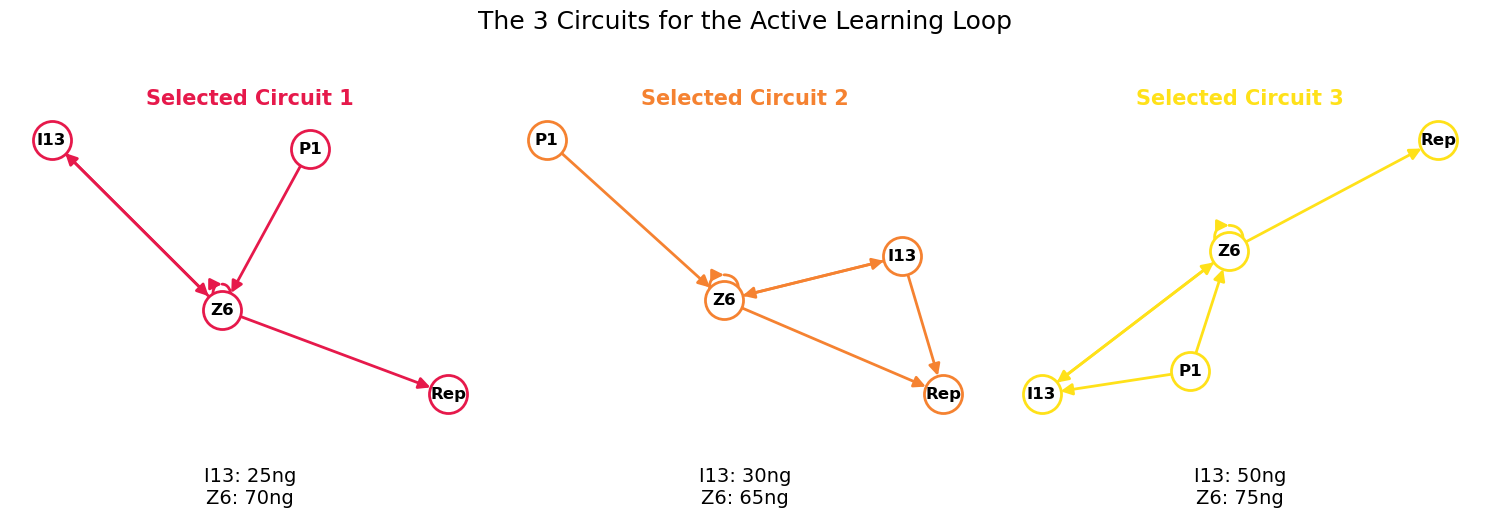

In [4]:
# Visualize the Selected Circuits

fig, axes = plt.subplots(1, len(selected_circuits), figsize=(5 * len(selected_circuits), 5))
if len(selected_circuits) == 1: axes = [axes]

TOPO_COLORS = ['#e6194B', '#f58231', '#ffe119']

for i, circuit in enumerate(selected_circuits):
    ax = axes[i]
    color = TOPO_COLORS[i % len(TOPO_COLORS)]
    
    G = nx.DiGraph(circuit.edge_list)
    pos = nx.spring_layout(G, seed=25)
    
    nx.draw(G, pos, ax=ax, node_color='white', edgecolors=color, linewidths=2, node_size=750, 
            with_labels=True, font_weight='bold', font_size=12, edge_color=color, width=2, arrowsize=17)
    
    ax.set_title(f"Selected Circuit {i+1}", color=color, fontweight='bold', fontsize=15)
    dose_str = "\n".join([f"{k}: {v}ng" for k, v in circuit.dose.items() if k!='Rep'])
    ax.text(0.5, -0.15, dose_str, transform=ax.transAxes, ha='center', va='top', fontsize=14)

plt.suptitle("The 3 Circuits for the Active Learning Loop", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [5]:
output_file = "selected_M_circuits.pkl"

with open(output_file, 'wb') as f:
    pickle.dump(selected_circuits, f)

print(f"✅ Saved selected circuits to '{output_file}'.")

✅ Saved selected circuits to 'selected_M_circuits.pkl'.
